# Data Cleanser

## **Part A** : Handling Missing Values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer , MissingIndicator , KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [2]:
data = pd.read_csv('patient_health.csv')

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P00001,69.0,Male,South,NaN,132.4,174.7,97.6,0
1,P00002,32.0,Female,North,21.6,106.1,194.9,87.4,0
2,P00003,NaN,Female,West,32.0,139.3,204.3,130.4,1
3,P00004,78.0,Male,North,27.7,113.7,185.6,85.1,0
4,P00005,38.0,Male,North,32.6,123.9,90.9,NaN,0
...,...,...,...,...,...,...,...,...,...
595,P00596,22.0,Female,North,30.5,121.0,194.4,169.1,1
596,P00597,20.0,Female,NaN,22.9,104.2,230.6,102.5,0
597,P00598,70.0,Male,West,NaN,135.9,161.6,79.0,0
598,P00599,40.0,Male,North,24.7,123.0,202.9,135.5,1


In [5]:
df.isnull().sum()

patient_id         0
age               42
gender            30
region            30
bmi               48
blood_pressure     0
cholesterol       48
glucose           48
disease_risk       0
dtype: int64

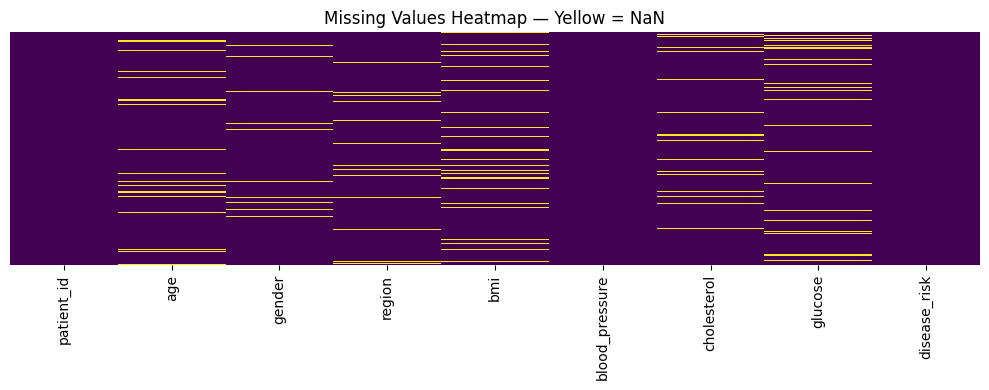

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False,
            cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap — Yellow = NaN')
plt.tight_layout()
plt.show()

Quick Check : Any missing values are still in dataset

"The dataset has 246 missing values spread across 6 columns. bmi, cholesterol, and glucose have the highest missing percentage (8%), followed by age (7%), and gender/region (5% each). No missing values exist in patient_id, blood_pressure, or disease_risk."

In [7]:
print("Any NaN : ",df.isnull().values.any())
print("Total NaN : ",df.isnull().sum().sum())

Any NaN :  True
Total NaN :  246


### 1.identifying missing values and provide a summary report(perchantage per column)

In [8]:
missing_pct = df.isnull().sum() / len(df) * 100

In [9]:
print("Percentage of Missing Values in Each Column : ")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

Percentage of Missing Values in Each Column : 
cholesterol    8.0
bmi            8.0
glucose        8.0
age            7.0
gender         5.0
region         5.0
dtype: float64


**Bar-Chart** for missing values per column in perchantage

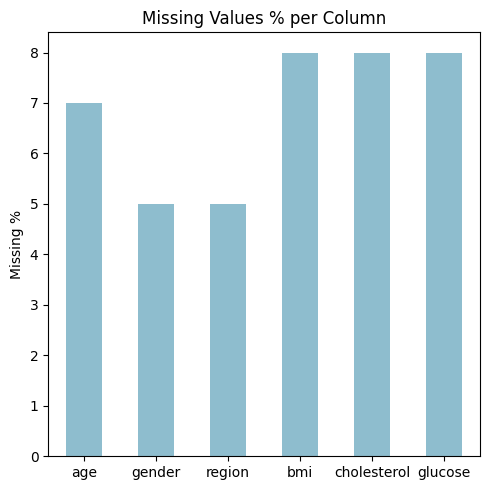

In [10]:
plt.figure(figsize=(5,5))
missing_pct[missing_pct > 0].plot(kind='bar', color="#8ebdce")
plt.title('Missing Values % per Column')
plt.ylabel('Missing %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.Apply the following imputation techniques and compare results : 

In [11]:
print("Missing values : ")
print(df.isnull().sum())

Missing values : 
patient_id         0
age               42
gender            30
region            30
bmi               48
blood_pressure     0
cholesterol       48
glucose           48
disease_risk       0
dtype: int64


In [12]:
mean_imputer = SimpleImputer(strategy='mean')

df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df['bmi'].values.reshape(-1, 1)),
    columns=['bmi']
)

In [13]:
print("After Mean Imputation : ")
print(df_mean)

After Mean Imputation : 
           bmi
0    26.065761
1    21.600000
2    32.000000
3    27.700000
4    32.600000
..         ...
595  30.500000
596  22.900000
597  26.065761
598  24.700000
599  25.900000

[600 rows x 1 columns]


"Mean imputation filled missing bmi values with the average value (26.07). This works well here since bmi is fairly symmetric, but it can slightly reduce the natural variation in the data."

In [14]:
freq_imputer = SimpleImputer(strategy='most_frequent')

df_freq = pd.DataFrame(
    freq_imputer.fit_transform(df['region'].values.reshape(-1, 1)),
    columns=['region']
)

In [15]:
print("After frequent Imputation : ")
print(df_freq)

After frequent Imputation : 
    region
0    South
1    North
2     West
3    North
4    North
..     ...
595  North
596  North
597   West
598  North
599   West

[600 rows x 1 columns]


In [16]:
frequent_imputer = SimpleImputer(strategy='most_frequent')

df_frequent = pd.DataFrame(
    frequent_imputer.fit_transform(df['gender'].values.reshape(-1, 1)),
    columns=['gender']
)

In [17]:
print("After frequent Imputation : ")
print(df_frequent)

After frequent Imputation : 
     gender
0      Male
1    Female
2    Female
3      Male
4      Male
..      ...
595  Female
596  Female
597    Male
598    Male
599  Female

[600 rows x 1 columns]


"Missing values in region and gender were filled with the most common category. This is a safe choice for categorical data with one dominant class, but it can slightly increase the size of the majority group."

In [18]:
from sklearn.impute import SimpleImputer, MissingIndicator

indicator = MissingIndicator(features='missing-only')
indicator_array = indicator.fit_transform(df)
print("Indicator array shape:", indicator_array.shape)

indicator_cols = [df.columns[i] + '_Missing' for i in indicator.features_]
df_indicator = pd.DataFrame(indicator_array.astype(int), columns=indicator_cols)

imputer = SimpleImputer(strategy='constant')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_final = pd.concat([df_imputed, df_indicator], axis=1)

Indicator array shape: (600, 6)


In [19]:
print(df_final.round(1))

    patient_id            age  gender         region            bmi  \
0       P00001           69.0    Male          South  missing_value   
1       P00002           32.0  Female          North           21.6   
2       P00003  missing_value  Female           West           32.0   
3       P00004           78.0    Male          North           27.7   
4       P00005           38.0    Male          North           32.6   
..         ...            ...     ...            ...            ...   
595     P00596           22.0  Female          North           30.5   
596     P00597           20.0  Female  missing_value           22.9   
597     P00598           70.0    Male           West  missing_value   
598     P00599           40.0    Male          North           24.7   
599     P00600  missing_value  Female           West           25.9   

    blood_pressure cholesterol        glucose disease_risk  age_Missing  \
0            132.4       174.7           97.6            0            0 

"Instead of just filling missing values, this step also created extra columns (like bmi_Missing, age_Missing) to track exactly where data was missing. This is useful because sometimes 'missingness' itself carries useful information for prediction."

In [20]:
def random_sample_impute(df, col, random_state=7):
    np.random.seed(random_state)

    null_count = df[col].isnull().sum()

    if null_count == 0:
        return df  

    random_values = df[col].dropna().sample(
        n=null_count,        
        replace=True,        
        random_state=random_state
    ).values
    
    df_copy = df.copy()
    df_copy.loc[df_copy[col].isnull(), col] = random_values

    return df_copy

num_cols = ['age','bmi', 'blood_pressure', 'cholesterol	','glucose','disease_risk']
df_imputed = df.copy()

In [21]:
print("After Random Sample Imputation : ")
print(df_imputed)

After Random Sample Imputation : 
    patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0       P00001  69.0    Male  South   NaN           132.4        174.7   
1       P00002  32.0  Female  North  21.6           106.1        194.9   
2       P00003   NaN  Female   West  32.0           139.3        204.3   
3       P00004  78.0    Male  North  27.7           113.7        185.6   
4       P00005  38.0    Male  North  32.6           123.9         90.9   
..         ...   ...     ...    ...   ...             ...          ...   
595     P00596  22.0  Female  North  30.5           121.0        194.4   
596     P00597  20.0  Female    NaN  22.9           104.2        230.6   
597     P00598  70.0    Male   West   NaN           135.9        161.6   
598     P00599  40.0    Male  North  24.7           123.0        202.9   
599     P00600   NaN  Female   West  25.9           115.7        201.1   

     glucose  disease_risk  
0       97.6             0  
1       87.4       

"This method filled missing values using random existing values from the same column. It keeps the original distribution shape better than mean imputation, but it adds some randomness, so results can vary each time."

In [22]:
num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

knn_imputer = KNNImputer(
    n_neighbors=5,           
    weights='distance'       
)

df_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df[num_cols]),
    columns=df[num_cols].columns
)

In [23]:
print("After KNN Imputation (k=5):")
print(df_imputed.round(2))

After KNN Imputation (k=5):
       age    bmi  blood_pressure  cholesterol  glucose
0    69.00  28.44           132.4        174.7    97.60
1    32.00  21.60           106.1        194.9    87.40
2    54.57  32.00           139.3        204.3   130.40
3    78.00  27.70           113.7        185.6    85.10
4    38.00  32.60           123.9         90.9   105.37
..     ...    ...             ...          ...      ...
595  22.00  30.50           121.0        194.4   169.10
596  20.00  22.90           104.2        230.6   102.50
597  70.00  26.24           135.9        161.6    79.00
598  40.00  24.70           123.0        202.9   135.50
599  51.53  25.90           115.7        201.1    60.30

[600 rows x 5 columns]


"KNN Imputation filled missing values based on the 5 most similar patients. This gave more realistic results because it considers relationships between age, bmi, blood_pressure, cholesterol, and glucose instead of just using one fixed value."

In [24]:
imputer = IterativeImputer(max_iter=10, random_state=42)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df[num_cols]),
    columns=df[num_cols].columns
)

print("After MICE Imputation : ")
print(df_imputed.round(2))

After MICE Imputation : 
       age    bmi  blood_pressure  cholesterol  glucose
0    69.00  26.08           132.4        174.7    97.60
1    32.00  21.60           106.1        194.9    87.40
2    52.82  32.00           139.3        204.3   130.40
3    78.00  27.70           113.7        185.6    85.10
4    38.00  32.60           123.9         90.9    99.94
..     ...    ...             ...          ...      ...
595  22.00  30.50           121.0        194.4   169.10
596  20.00  22.90           104.2        230.6   102.50
597  70.00  26.09           135.9        161.6    79.00
598  40.00  24.70           123.0        202.9   135.50
599  52.80  25.90           115.7        201.1    60.30

[600 rows x 5 columns]


"MICE imputation predicted missing values using patterns from all numeric columns together. It's one of the most advanced methods here and gave values close to KNN, confirming the data relationships are consistent."

## Part B : Handling Outliers

### 3. Detect and Remove outliers using : 

### **Z-Score method** : Identify patients with extreme cholesterol or glucose values.

In [25]:
df_Mean_Cl = df[['cholesterol']].mean()
df_Std_Cl = df[['cholesterol']].std()

df_Mean_Gl = df[['glucose']].mean()
df_Std_Gl = df[['glucose']].std()

In [26]:
print("Mean Values of Cholesterol: ", df_Mean_Cl.values)
print("Standard Deviation Values of Cholesterol: ", df_Std_Cl.values)
print()
print("Mean Values of Glucose: ", df_Mean_Gl.values)
print("Standard Deviation Values of Glucose: ", df_Std_Gl.values)

Mean Values of Cholesterol:  [188.62681159]
Standard Deviation Values of Cholesterol:  [38.26555798]

Mean Values of Glucose:  [100.00724638]
Standard Deviation Values of Glucose:  [27.05843951]


In [27]:
df['z_score_cholesterol'] = (df['cholesterol'] - df_Mean_Cl) / df_Std_Cl
df['z_score_glucose'] = (df['glucose'] - df_Mean_Gl) / df_Std_Gl

print("Z-scores for Cholesterol and Glucose : ")
print(df[['z_score_cholesterol', 'z_score_glucose']])

Z-scores for Cholesterol and Glucose : 
     z_score_cholesterol  z_score_glucose
0                    NaN              NaN
1                    NaN              NaN
2                    NaN              NaN
3                    NaN              NaN
4                    NaN              NaN
..                   ...              ...
595                  NaN              NaN
596                  NaN              NaN
597                  NaN              NaN
598                  NaN              NaN
599                  NaN              NaN

[600 rows x 2 columns]


In [28]:
threshold = 3
outliers = df[df['z_score_cholesterol'].abs() > threshold]
outliers = df[df['z_score_glucose'].abs() > threshold]
print(f"\nOutliers detected (|Z| > {threshold}):")
print(outliers[['cholesterol', 'glucose', 'z_score_cholesterol']])


Outliers detected (|Z| > 3):
Empty DataFrame
Columns: [cholesterol, glucose, z_score_cholesterol]
Index: []


In [29]:
df_clean_Cl = df[df['z_score_cholesterol'].abs() <= threshold].copy()
df_clean_Gl = df[df['z_score_glucose'].abs() <= threshold].copy()

print(f"Rows before cleaning : {len(df)}")
print(f"Rows after cleaning (Cholesterol) : {len(df_clean_Cl)}")
print(f"Rows after cleaning (Glucose) : {len(df_clean_Gl)}")

Rows before cleaning : 600
Rows after cleaning (Cholesterol) : 0
Rows after cleaning (Glucose) : 0


In [30]:
print("Mean Values : ")
print(f"Cholesterol : {df_Mean_Cl}")
print(f"Glucose : {df_Mean_Gl}")

Mean Values : 
Cholesterol : cholesterol    188.626812
dtype: float64
Glucose : glucose    100.007246
dtype: float64


"Using a threshold of 3 standard deviations, no outliers were found in cholesterol or glucose. This means the Z-score method was too lenient for this dataset — the extreme values weren't extreme enough to cross a full 3 SD gap."

### **IQR** method : inquartile range to detect unusual **BMI** values.

In [31]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

In [32]:
Lower_fence = Q1 - 1.5 * IQR
Upper_fence = Q3 + 1.5 * IQR

print(f"If Lower Fence for below from this data is {Lower_fence} than consider it as outlier.")
print(f"If Upper Fence for below from this data is {Upper_fence} than consider it as outlier.")

If Lower Fence for below from this data is 13.0375 than consider it as outlier.
If Upper Fence for below from this data is 38.737500000000004 than consider it as outlier.


In [33]:
outlier_mask = (df['bmi'] < Lower_fence) | (df['bmi'] > Upper_fence)
print(f"Outliers in {'bmi'} : ")
print()
print(df[outlier_mask][['bmi']])

Outliers in bmi : 

      bmi
154  40.8
231  40.7
280  10.0
337  55.0
578  10.0


In [34]:
df_clean = df[~outlier_mask].copy()

print(f"Rows before : {len(df)} | Rows after cleaning : {len(df_clean)}")
print(f"Outliers removed from the data. Now you can use this cleaned data for further analysis or modeling.")
print()
print(f"Mean values of bmi before : {df['bmi'].mean()}")
print(f"Mean values of bmi after : {df_clean['bmi'].mean()}")

Rows before : 600 | Rows after cleaning : 595
Outliers removed from the data. Now you can use this cleaned data for further analysis or modeling.

Mean values of bmi before : 26.065760869565217
Mean values of bmi after : 26.017915904936014


In [35]:
df_clean

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,z_score_cholesterol,z_score_glucose
0,P00001,69.0,Male,South,NaN,132.4,174.7,97.6,0,NaN,NaN
1,P00002,32.0,Female,North,21.6,106.1,194.9,87.4,0,NaN,NaN
2,P00003,NaN,Female,West,32.0,139.3,204.3,130.4,1,NaN,NaN
3,P00004,78.0,Male,North,27.7,113.7,185.6,85.1,0,NaN,NaN
4,P00005,38.0,Male,North,32.6,123.9,90.9,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,P00596,22.0,Female,North,30.5,121.0,194.4,169.1,1,NaN,NaN
596,P00597,20.0,Female,NaN,22.9,104.2,230.6,102.5,0,NaN,NaN
597,P00598,70.0,Male,West,NaN,135.9,161.6,79.0,0,NaN,NaN
598,P00599,40.0,Male,North,24.7,123.0,202.9,135.5,1,NaN,NaN


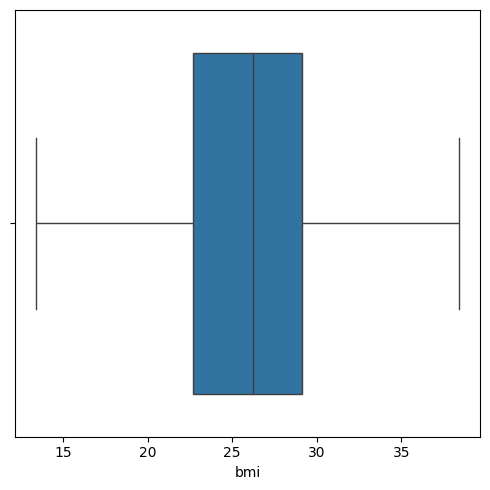

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
sns.boxplot(data=df_clean, x="bmi")
plt.tight_layout()
plt.show()

"The IQR method found 5 outliers in bmi, both unusually low (like 10) and unusually high (like 55). This method is more sensitive than Z-score and better suited for skewed data."

### **Percentile method** : Cap values below 1st percentile and above 99th percentile.

In [37]:
Lower_pct = 0.05
Upper_pct = 0.95

Lower_Bound = df['bmi'].quantile(Lower_pct)
Upper_Bound = df['bmi'].quantile(Upper_pct)

print(f"5th Percentile (Lower Bound) of bmi: {Lower_Bound}")
print(f"95th Percentile (Upper Bound) of bmi: {Upper_Bound}")
print()
print(f"Normal range of bmi values are between {Lower_Bound} to {Upper_Bound}")

5th Percentile (Lower Bound) of bmi: 17.955
95th Percentile (Upper Bound) of bmi: 34.144999999999996

Normal range of bmi values are between 17.955 to 34.144999999999996


In [38]:
Outlier_mask_pct = (
    (df['bmi'] < Lower_Bound) | (df['bmi'] > Upper_Bound)
)

print(df[Outlier_mask_pct][['bmi']])
print(f'Total Outliers : {Outlier_mask_pct.sum()}')

      bmi
6    17.8
48   17.0
55   15.8
58   17.5
71   34.3
108  38.4
118  38.0
121  34.9
136  35.1
147  36.9
154  40.8
166  16.7
169  36.0
171  34.9
172  17.8
184  17.7
188  14.8
200  15.5
230  15.5
231  40.7
243  36.0
253  34.2
262  17.6
273  17.8
280  10.0
284  14.8
293  16.9
294  37.6
308  16.4
318  35.2
337  55.0
342  35.1
346  37.1
357  17.6
363  16.4
368  17.9
381  36.6
385  35.7
387  34.6
418  36.8
440  38.3
444  13.4
450  17.0
473  37.4
494  16.2
495  36.3
500  14.5
503  14.6
521  34.6
549  35.0
558  17.3
559  16.3
578  10.0
588  37.5
590  16.5
592  35.1
Total Outliers : 56


In [39]:
df_clean_bmi = df[~Outlier_mask_pct].copy()

print(f"Rows before : {len(df)} | Rows after : {len(df_clean_bmi)}")
print()
print(f"bmi before : {df['bmi'].mean()}")
print(f"bmi after : {df_clean_bmi['bmi'].mean()}")
print()
print(f"bmi Max before : {df['bmi'].max()}")
print(f"bmi Max after : {df_clean_bmi['bmi'].max()}")

Rows before : 600 | Rows after : 544

bmi before : 26.065760869565217
bmi after : 26.013911290322582

bmi Max before : 55.0
bmi Max after : 34.1


In [40]:
df_clean_bmi 

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,z_score_cholesterol,z_score_glucose
0,P00001,69.0,Male,South,NaN,132.4,174.7,97.6,0,NaN,NaN
1,P00002,32.0,Female,North,21.6,106.1,194.9,87.4,0,NaN,NaN
2,P00003,NaN,Female,West,32.0,139.3,204.3,130.4,1,NaN,NaN
3,P00004,78.0,Male,North,27.7,113.7,185.6,85.1,0,NaN,NaN
4,P00005,38.0,Male,North,32.6,123.9,90.9,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,P00596,22.0,Female,North,30.5,121.0,194.4,169.1,1,NaN,NaN
596,P00597,20.0,Female,NaN,22.9,104.2,230.6,102.5,0,NaN,NaN
597,P00598,70.0,Male,West,NaN,135.9,161.6,79.0,0,NaN,NaN
598,P00599,40.0,Male,North,24.7,123.0,202.9,135.5,1,NaN,NaN


"Capping at the 5th and 95th percentile flagged 56 outliers — much more than IQR. This shows the percentile method is more aggressive since it uses fixed cutoffs rather than the data's actual spread."

### 4.Apply **Winsorization** to cap extreme outliers instead of removing them.

In [52]:
df['bmi_winsorized'] = df['bmi'].clip(lower=Lower_Bound, upper=Upper_Bound)

print(df['bmi_winsorized'].tolist())
print()
print(f"Mean after : {df['bmi_winsorized'].mean()}")
print(f"Mean before : {df['bmi'].mean()}")

[nan, 21.6, 32.0, 27.7, 32.6, 20.3, 17.955, 28.3, 27.2, 27.5, 30.7, 28.1, 28.0, 29.6, 28.5, 30.3, 31.0, 33.7, 22.8, 28.4, 24.1, 21.8, 22.6, 28.5, 28.1, 28.0, 24.9, nan, 30.1, 18.6, 26.1, nan, 29.8, 19.2, 33.5, 27.1, 27.3, 24.0, 28.7, 26.2, 32.0, 18.8, nan, 28.0, 25.1, 24.0, 24.2, nan, 17.955, nan, 23.6, 26.6, 27.8, 23.4, 25.3, 17.955, 29.7, 31.4, 17.955, nan, 19.9, 25.1, 29.2, 30.9, 31.6, 32.6, 24.9, 20.3, nan, 29.2, 19.9, 34.144999999999996, 30.5, 25.0, 22.4, 22.7, 26.4, 24.9, 30.8, 24.3, 28.5, 25.9, 27.3, 24.8, 29.5, 29.6, 28.3, 29.0, nan, 27.6, 32.2, 28.5, 20.8, 25.8, 27.9, 22.2, 19.2, 24.4, 22.3, 25.9, 18.0, 28.8, 22.8, 31.0, 24.6, 25.9, 25.1, 22.6, 34.144999999999996, 23.5, 31.1, 20.5, 27.9, 28.4, 25.9, 23.1, 24.7, 24.0, 34.144999999999996, 25.9, 28.6, 34.144999999999996, 21.6, 26.2, nan, nan, 25.1, 22.3, 27.0, 20.7, 30.9, 29.1, 23.5, 23.8, 27.4, 22.0, 34.144999999999996, 27.8, 28.0, 29.4, 23.1, 31.4, 26.6, 30.8, 25.0, 32.6, 28.0, 34.144999999999996, nan, 27.0, nan, 23.4, 29.1, na

"Winsorization capped bmi values between 17.96 and 34.14. Extreme values (like 10 or 55) were pulled closer to normal, instead of being removed. This kept all 600 patients while reducing the effect of outliers — a safer method than deleting rows."

### 5.Compare dataset shape and summary **before vs after outliers treatment**.

### Dataset before outliers handling.

In [42]:
df_imputed

,age,bmi,blood_pressure,cholesterol,glucose
0,69.000000,26.077300,132.4,174.7,97.60000
1,32.000000,21.600000,106.1,194.9,87.40000
2,52.818972,32.000000,139.3,204.3,130.40000
3,78.000000,27.700000,113.7,185.6,85.10000
4,38.000000,32.600000,123.9,90.9,99.93716
...,...,...,...,...,...
595,22.000000,30.500000,121.0,194.4,169.10000
596,20.000000,22.900000,104.2,230.6,102.50000
597,70.000000,26.093243,135.9,161.6,79.00000
598,40.000000,24.700000,123.0,202.9,135.50000


### Dataset after outliers handling.

- When i tried **Z-Score method** that givees me '0' outliers.
- It means there are '0' outliers in Cholesterol and Glucose columns.

- After i tried **IQR method** And here are the results.

In [43]:
print(f"This is lower-fence of bmi : {Lower_fence}")
print(f"This is upper-fence of bmi : {Upper_fence}")

This is lower-fence of bmi : 13.0375
This is upper-fence of bmi : 38.737500000000004


- There are only '5' outliers founded in **IQR Method**.

In [44]:
df[outlier_mask][['bmi']]

,bmi
154,40.8
231,40.7
280,10.0
337,55.0
578,10.0


- And here's the cleaned Data.

In [45]:
df_clean

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,z_score_cholesterol,z_score_glucose
0,P00001,69.0,Male,South,NaN,132.4,174.7,97.6,0,NaN,NaN
1,P00002,32.0,Female,North,21.6,106.1,194.9,87.4,0,NaN,NaN
2,P00003,NaN,Female,West,32.0,139.3,204.3,130.4,1,NaN,NaN
3,P00004,78.0,Male,North,27.7,113.7,185.6,85.1,0,NaN,NaN
4,P00005,38.0,Male,North,32.6,123.9,90.9,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,P00596,22.0,Female,North,30.5,121.0,194.4,169.1,1,NaN,NaN
596,P00597,20.0,Female,NaN,22.9,104.2,230.6,102.5,0,NaN,NaN
597,P00598,70.0,Male,West,NaN,135.9,161.6,79.0,0,NaN,NaN
598,P00599,40.0,Male,North,24.7,123.0,202.9,135.5,1,NaN,NaN


- After then i tried **Percentile Method**.

In [46]:
print(f"5th Percentile (Lower Bound) of bmi : {Lower_Bound}")
print(f"95th percentile (Upper Bound) of bmi : {Upper_Bound}")

5th Percentile (Lower Bound) of bmi : 17.955
95th percentile (Upper Bound) of bmi : 34.144999999999996


- There are many outliers founded in **Percentile  Method**.

In [47]:
df[Outlier_mask_pct][['bmi']]

,bmi
6,17.8
48,17.0
55,15.8
58,17.5
71,34.3
108,38.4
118,38.0
121,34.9
136,35.1
147,36.9


## **Part C** : Final Clean Dataset 

### 6. Present the final **cleaned dataset** with :

- All missing values treated appropriately.
- All outliers handled using suitable method.

All missing values treated appropriately.

In [48]:
df_mean = df.copy()
df_frequent = df.copy()
df_final = df.copy()
df_imputed = df.copy()

In [49]:
df_mean.to_csv('df_mean.csv', index=False)
df_frequent.to_csv('df_frequent.csv', index=False)
df_final.to_csv('df_final.csv', index=False)
df_imputed.to_csv('df_imputed.csv', index=False)

All outliers handled using suitable method

In [50]:
df_clean.to_csv('df_clean_by_Outliers.csv', index=False)

In [51]:
df_clean_bmi.to_csv('df_clean_bmi.csv', index=False)

### 7.Provide a **brief report** explaining : 



#### Which imputation strategy was most effective?
Simple Imputer with **mean** worked fine for `bmi` since it's roughly symmetric, but
for skewed numeric columns median would be safer. For categorical columns
(`region`, `gender`), **Most Frequent imputation** was the simplest and most
interpretable choice since each had one dominant category. Among the more advanced
methods, **KNN Imputer** was the most effective overall — it used relationships
between `age`, `bmi`, `blood_pressure`, `cholesterol`, and `glucose` to fill values,
so the imputed numbers stayed consistent with each patient's other health metrics,
unlike mean/median which ignore those relationships.

#### Which outlier handling method preserved data quality best?
- **Z-score method** found 0 outliers in cholesterol/glucose, meaning it was too
  lenient (threshold of 3 SD didn't catch anything in this dataset).
- **IQR method** found 5 outliers in `bmi` — more sensitive than Z-score.
- **Percentile method** (5th/95th) flagged the most outliers in `bmi`, since it isn't
  based on distribution shape at all, just fixed cutoffs — this made it the most
  aggressive method.
- **Winsorization** preserved data quality best because it capped the extreme `bmi`
  values instead of deleting rows, keeping the full sample size intact while still
  reducing the influence of extreme values.

#### How did data cleaning improve dataset usability?
- All missing values in `age`, `bmi`, `region`, `gender`, `cholesterol`, and `glucose`
  were filled, so the dataset can now be used directly for modeling without errors.
- Extreme values in `bmi` were identified and either removed or capped, preventing
  them from skewing statistics like the mean or distorting a downstream ML model.
- The cleaned dataset (`df_final`, `df_clean`, `df_clean_bmi`) is now consistent,
  complete, and ready for exploratory analysis or machine learning tasks such as
  predicting `disease_risk`.